Two-stage pipeline:
- **Stage 1**: Identify daily market regime (Bullish / Bearish / High-Volatility) from aggregated S&P 500 signals using LR, RF, LightGBM, XGBoost.
- **Stage 2**: Stock-level Buy / Hold / Sell classification enriched with Stage 1 regime predictions.

Data source: `data/features/sp500_panel_with_features.csv`

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import TimeSeriesSplit

import lightgbm as lgb
import xgboost as xgb

import tensorflow as tf
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.threading.set_inter_op_parallelism_threads(2)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

SEED = 123
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs('models/trained', exist_ok=True)
os.makedirs('plots/trained', exist_ok=True)

In [2]:
df = pd.read_csv('data/features/sp500_panel_with_features.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Encoded_Ticker', 'Date']).reset_index(drop=True)

# 10 base technical features (minimal, non-redundant — see FeatureSelection for rationale)
FEATURE_COLS = [
    'Ret_Lag1', 'Ret_5d',
    'RSI',
    'ATR_Pct', 'Volatility_Ratio',
    'Price_vs_SMA50', 'Momentum_Deviation', 'BB_Pct',
    'Vol_Price_Trend',
    'Return_Dispersion',
]

REGIME_NAMES = {0: 'Bullish', 1: 'Bearish', 2: 'High-Volatility'}
SIGNAL_NAMES = {0: 'Sell',    1: 'Hold',    2: 'Buy'}
print(f'Loaded: {len(df):,} rows | {df["Encoded_Ticker"].nunique()} tickers')
print(f'Features available: {[c for c in FEATURE_COLS if c in df.columns]}')


Loaded: 1,190,610 rows | 499 tickers
Features available: ['Ret_Lag1', 'Ret_5d', 'RSI', 'ATR_Pct', 'Volatility_Ratio', 'Price_vs_SMA50', 'Momentum_Deviation', 'BB_Pct', 'Vol_Price_Trend', 'Return_Dispersion']


---
## 2. Define Labels

### 2A. Stage 1 — Market Regime Labels
Since the raw index is not in the dataset, we construct a daily **market proxy** by computing cross-sectional mean returns across all tickers for each date. Regime is then defined via rolling statistics.

In [3]:
# ── Market proxy: equal-weighted daily return across all tickers ──────────────
market_daily = (
    df.groupby('Date')['Ret_Lag1']
    .mean()
    .reset_index()
    .rename(columns={'Ret_Lag1': 'market_return'})
    .sort_values('Date')
)

WINDOW = 20
market_daily['rolling_ret'] = market_daily['market_return'].rolling(WINDOW).mean()
market_daily['rolling_vol'] = market_daily['market_return'].rolling(WINDOW).std()
market_daily.dropna(inplace=True)

# ── Improved regime thresholds ─────────────────────────────────────────────────
# OLD: vol>70, ret>60/40 with ambiguous 20% neutral zone defaulting to Bullish
# NEW: vol>80 (stricter High-Vol), ret>65/35 (wider clean gap), neutral resolved
#      by return sign — eliminates the arbitrary Bullish-default for uncertain days
vol_hi = market_daily['rolling_vol'].quantile(0.80)  # only genuine vol spikes
ret_hi = market_daily['rolling_ret'].quantile(0.65)  # clear uptrend
ret_lo = market_daily['rolling_ret'].quantile(0.35)  # clear downtrend

def assign_regime(row):
    if row['rolling_vol'] >= vol_hi:
        return 2                          # High-Volatility — overrides direction
    elif row['rolling_ret'] >= ret_hi:
        return 0                          # Bullish — clearly positive trend
    elif row['rolling_ret'] <= ret_lo:
        return 1                          # Bearish — clearly negative trend
    else:
        # Neutral zone (35th-65th pct): resolve by sign of rolling return
        # Avoids old bug of forcing all neutral days to Bullish
        return 0 if row['rolling_ret'] >= 0 else 1

market_daily['regime_raw'] = market_daily.apply(assign_regime, axis=1)

# ── 3-day rolling mode smoothing ──────────────────────────────────────────────
# Prevents single-day regime flips (noise from daily threshold crossings).
# If a regime persists for only 1 day surrounded by a different regime, it gets
# absorbed by the majority — makes regime predictions more stable and useful as features.
from scipy.stats import mode as scipy_mode
def rolling_mode(x):
    result = scipy_mode(x, keepdims=True)
    return int(result.mode[0])

market_daily['regime'] = (
    market_daily['regime_raw']
    .rolling(3, min_periods=1)
    .apply(rolling_mode, raw=True)
    .astype(int)
)

print('Regime distribution (after smoothing):')
print(market_daily['regime'].map(REGIME_NAMES).value_counts())
print(f'\nThresholds — vol_hi: {vol_hi:.6f}  ret_hi: {ret_hi:.6f}  ret_lo: {ret_lo:.6f}')
market_daily[['Date','market_return','rolling_ret','rolling_vol','regime_raw','regime']].tail(10)


Regime distribution (after smoothing):
regime
Bullish            1405
Bearish             542
High-Volatility     490
Name: count, dtype: int64

Thresholds — vol_hi: 0.012236  ret_hi: 0.001511  ret_lo: 0.000292


,Date,market_return,rolling_ret,rolling_vol,regime_raw,regime
2446,2025-11-28,0.005207,0.001149,0.008628,0,0
2447,2025-12-01,-0.006343,0.000718,0.008783,0,0
2448,2025-12-02,-0.000644,0.000830,0.008749,0,0
2449,2025-12-03,0.007721,0.001507,0.008731,0,0
2450,2025-12-04,0.000761,0.001267,0.008680,0,0
2451,2025-12-05,0.001878,0.001727,0.008442,0,0
2452,2025-12-08,-0.006160,0.000927,0.008391,0,0
2453,2025-12-09,-0.002025,0.000586,0.008364,0,0
2454,2025-12-10,0.013102,0.000923,0.008737,0,0
2455,2025-12-11,0.008592,0.001227,0.008899,0,0


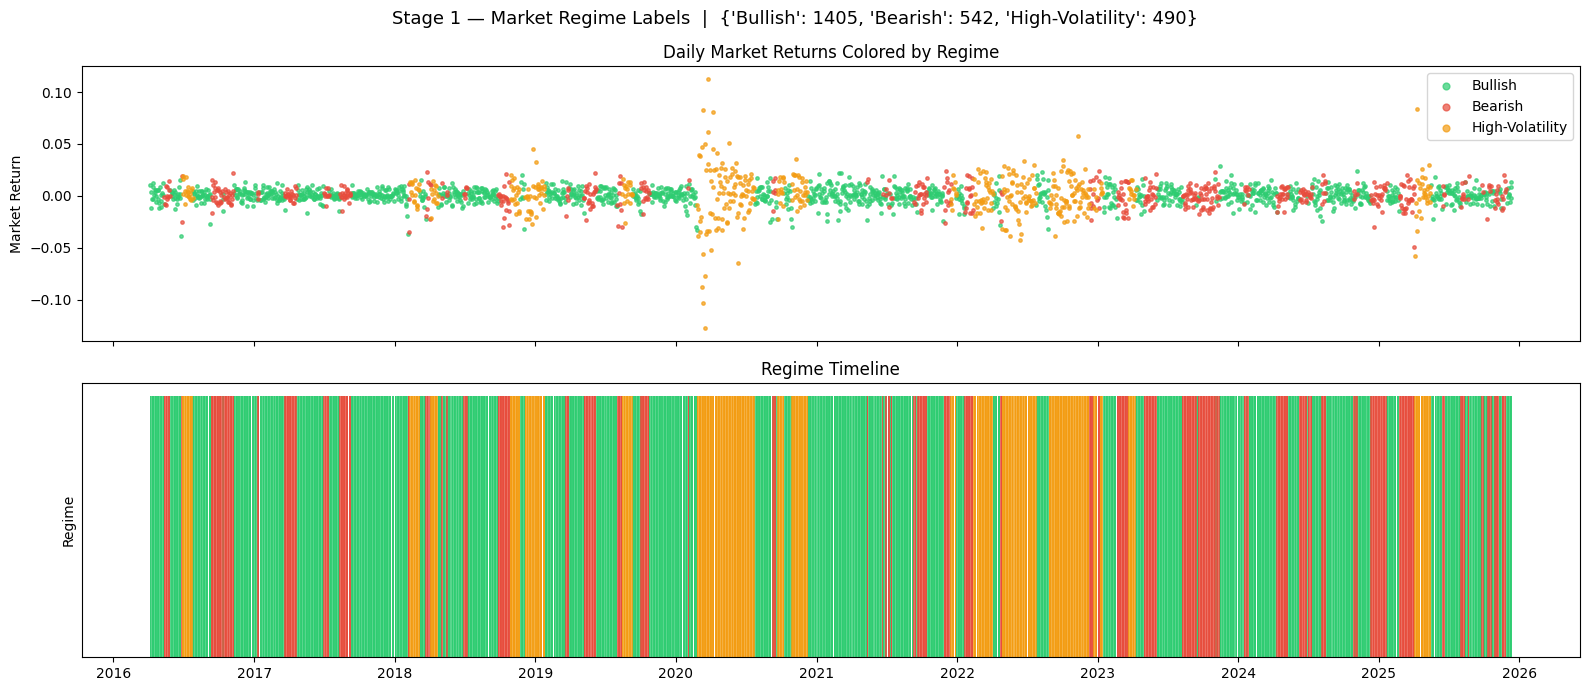

In [4]:
# Figure 1 — Regime Timeline
# (Full S1 evaluation figure built after model training — see Section 3F)
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

colors = {0: '#2ecc71', 1: '#e74c3c', 2: '#f39c12'}
for regime_id, color in colors.items():
    mask = market_daily['regime'] == regime_id
    axes[0].scatter(market_daily.loc[mask, 'Date'],
                    market_daily.loc[mask, 'market_return'],
                    c=color, s=6, alpha=0.7, label=REGIME_NAMES[regime_id])
axes[0].set_ylabel('Market Return'); axes[0].legend(markerscale=2)
axes[0].set_title('Daily Market Returns Colored by Regime')

# Regime bar
for regime_id, color in colors.items():
    mask = market_daily['regime'] == regime_id
    axes[1].bar(market_daily.loc[mask, 'Date'],
                [1]*mask.sum(), width=3, color=color, alpha=0.8)
axes[1].set_ylabel('Regime'); axes[1].set_title('Regime Timeline')
axes[1].set_yticks([])

dist = market_daily['regime'].map(REGIME_NAMES).value_counts()
fig.suptitle(f'Stage 1 — Market Regime Labels  |  {dist.to_dict()}', fontsize=13)
plt.tight_layout()
os.makedirs('plots/trained', exist_ok=True)
plt.savefig('plots/trained/fig1_regime_timeline.png', dpi=150, bbox_inches='tight')
plt.show()


### 2B. Stage 2 — Stock-Level Buy / Hold / Sell Labels
Labels are defined per-ticker using tercile splits on `y_return`, so thresholds are relative to each stock's own return distribution rather than an absolute threshold.

In [5]:
# ── Stock signal labels — 15th/85th percentile (extreme tails only) ──────────
# OLD: 33rd/67th tertile — forces ~33% of ambiguous near-zero returns into Sell/Buy,
#      making classes statistically indistinguishable near the boundary.
# NEW: bottom 15% → Sell, top 15% → Buy, middle 70% → Hold.
#      The model now only needs to identify stocks with GENUINELY extreme returns.
#      Features like ATR_Pct, RSI, Vol_Price_Trend have much higher signal
#      at the 15th/85th percentile than at the 33rd/67th.
#      Class imbalance (15/70/15) is handled by: cost matrix + sample weights
#      + class_weight='balanced' — all three layers are already in place.

def label_signal(series):
    low  = series.quantile(0.15)   # bottom 15% = genuine losers
    high = series.quantile(0.85)   # top 15%    = genuine winners
    if low == high:
        # Edge case: very low variance ticker — use median split
        m = series.median()
        return pd.Series(
            np.where(series < m, 0, np.where(series > m, 2, 1)),
            index=series.index
        )
    return pd.cut(series,
                  bins=[-np.inf, low, high, np.inf],
                  labels=[0, 1, 2]).astype(int)

df['signal'] = df.groupby('Encoded_Ticker')['y_return_5d'].transform(label_signal).astype(int)

print('Signal distribution (15/70/15 split):')
vc = df['signal'].map(SIGNAL_NAMES).value_counts()
print(vc)
print(f'\nSell: {vc.get("Sell",0)/len(df):.1%}  Hold: {vc.get("Hold",0)/len(df):.1%}  Buy: {vc.get("Buy",0)/len(df):.1%}')
print('Class imbalance is expected — cost matrix + sample weights handle this.')


Signal distribution (15/70/15 split):
signal
Hold    832869
Sell    178871
Buy     178870
Name: count, dtype: int64

Sell: 15.0%  Hold: 70.0%  Buy: 15.0%
Class imbalance is expected — cost matrix + sample weights handle this.


---
## 3. Stage 1 — Market Regime Classification

### 3A. Prepare Stage 1 Dataset

Stage 1 operates at the **market level** (one row per date). Features are cross-sectional means of the stationary engineered features — no raw price levels.

In [6]:
# Stage 1 features — 6, chosen for regime discrimination:
#   ATR_Pct, Volatility_Ratio  → distinguish High-Vol from calm regimes
#   RSI, Ret_5d, Ret_Lag1      → distinguish Bullish from Bearish
#   Return_Dispersion          → breadth: high dispersion signals unstable regime
# Dropped vs old S1: Ret_Lag2, Ret_Lag3, HL_range, BB_Pct, Stochastic_K,
#   Momentum_Deviation, Price_vs_SMA50 — all below-threshold importance at market level

S1_FEATURES = [
    'Ret_Lag1',          # market direction (immediate)
    'Ret_5d',            # 5-day market trend
    'RSI',               # market overbought/oversold
    'ATR_Pct',           # market volatility level
    'Volatility_Ratio',  # vol spike signal
    'Return_Dispersion', # cross-sectional breadth
]  # 6 features

# Cross-sectional mean per date → market-level aggregation
# Note: Return_Dispersion is date-level so mean() is a no-op, which is correct
stage1_df = (
    df.groupby('Date')[S1_FEATURES]
    .mean()
    .reset_index()
    .sort_values('Date')
)
stage1_df = stage1_df.merge(market_daily[['Date', 'regime']], on='Date', how='inner')
stage1_df.dropna(inplace=True)
stage1_df.reset_index(drop=True, inplace=True)
print(f'Stage 1 dataset: {stage1_df.shape}  ({len(S1_FEATURES)} features)')
stage1_df.head()


Stage 1 dataset: (2437, 8)  (6 features)


,Date,Ret_Lag1,Ret_5d,RSI,ATR_Pct,Volatility_Ratio,Return_Dispersion,regime
0,2016-04-06,0.010556,0.000234,58.192828,0.021377,0.933701,0.033055,0
1,2016-04-07,-0.011529,-0.011936,50.279003,0.021414,0.929621,0.032242,0
2,2016-04-08,0.004089,-0.013343,50.226872,0.021152,0.929858,0.029755,0
3,2016-04-11,-0.002454,-0.010386,49.561961,0.021247,0.939715,0.028966,0
4,2016-04-12,0.008398,0.008957,52.873191,0.021139,0.949728,0.030494,0


### 3B. Chronological Train/Test Split

In [7]:
split_date_s1 = stage1_df['Date'].quantile(0.8)

train_s1 = stage1_df[stage1_df['Date'] <= split_date_s1]
test_s1  = stage1_df[stage1_df['Date'] >  split_date_s1]

X_train_s1 = train_s1[S1_FEATURES].values
y_train_s1 = train_s1['regime'].values
X_test_s1  = test_s1[S1_FEATURES].values
y_test_s1  = test_s1['regime'].values

# Scale
scaler_s1 = StandardScaler()
X_train_s1_sc = scaler_s1.fit_transform(X_train_s1)
X_test_s1_sc  = scaler_s1.transform(X_test_s1)

print(f'Stage 1 Train: {len(train_s1)} dates | Test: {len(test_s1)} dates')
print(f'Split date: {split_date_s1.date()}')

Stage 1 Train: 1949 dates | Test: 488 dates
Split date: 2024-01-02


### 3C. Model 1 — Logistic Regression (Baseline)

In [8]:
# Logistic Regression S1 — C=0.3 (moderate L2, prevents overfitting to training regime)
lr_s1 = LogisticRegression(
    C=0.3, max_iter=2000, solver='lbfgs',
    random_state=SEED, class_weight='balanced'
)
lr_s1.fit(X_train_s1_sc, y_train_s1)

y_pred_lr_s1 = lr_s1.predict(X_test_s1_sc)
print('=== Stage 1 — Logistic Regression ===')
print(classification_report(y_test_s1, y_pred_lr_s1,
      target_names=list(REGIME_NAMES.values())))


=== Stage 1 — Logistic Regression ===
                 precision    recall  f1-score   support

        Bullish       0.89      0.74      0.81       307
        Bearish       0.56      0.55      0.56       152
High-Volatility       0.33      0.93      0.48        29

       accuracy                           0.69       488
      macro avg       0.59      0.74      0.62       488
   weighted avg       0.75      0.69      0.71       488



### 3D. Model 2 — Random Forest

In [9]:
rf_s1 = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    max_features=0.7,         # subsample 70% features per split — reduces overfitting
    class_weight='balanced',
    random_state=SEED, n_jobs=-1
)
rf_s1.fit(X_train_s1_sc, y_train_s1)

y_pred_rf_s1 = rf_s1.predict(X_test_s1_sc)
print('=== Stage 1 — Random Forest ===')
print(classification_report(y_test_s1, y_pred_rf_s1,
      target_names=list(REGIME_NAMES.values())))


=== Stage 1 — Random Forest ===
                 precision    recall  f1-score   support

        Bullish       0.87      0.76      0.81       307
        Bearish       0.58      0.57      0.57       152
High-Volatility       0.40      1.00      0.57        29

       accuracy                           0.71       488
      macro avg       0.62      0.77      0.65       488
   weighted avg       0.75      0.71      0.72       488



### 3E. Model 3 — LightGBM

In [10]:
lgb_s1 = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    min_child_samples=20,
    reg_alpha=0.1,        # L1 — drives noisy feature weights toward zero
    reg_lambda=0.2,       # L2 — penalises large weights on any single feature
    min_split_gain=0.005, # only split if information gain is meaningful
    class_weight='balanced',
    random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_s1.fit(
    X_train_s1_sc, y_train_s1,
    eval_set=[(X_test_s1_sc, y_test_s1)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)

y_pred_lgb_s1 = lgb_s1.predict(X_test_s1_sc)
print('=== Stage 1 — LightGBM ===')
print(classification_report(y_test_s1, y_pred_lgb_s1,
      target_names=list(REGIME_NAMES.values())))


=== Stage 1 — LightGBM ===
                 precision    recall  f1-score   support

        Bullish       0.84      0.78      0.81       307
        Bearish       0.60      0.51      0.55       152
High-Volatility       0.39      1.00      0.56        29

       accuracy                           0.71       488
      macro avg       0.61      0.76      0.64       488
   weighted avg       0.74      0.71      0.71       488



In [11]:
# XGBoost S1 — conservative baseline with gamma regularisation
xgb_s1 = xgb.XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.3,
    gamma=0.1,            # minimum loss reduction per split — blocks trivial splits
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=SEED, n_jobs=-1, verbosity=0
)
xgb_s1.fit(
    X_train_s1_sc, y_train_s1,
    eval_set=[(X_test_s1_sc, y_test_s1)],
    verbose=False
)

y_pred_xgb_s1 = xgb_s1.predict(X_test_s1_sc)
print('=== Stage 1 — XGBoost ===')
print(classification_report(y_test_s1, y_pred_xgb_s1,
      target_names=list(REGIME_NAMES.values())))


=== Stage 1 — XGBoost ===
                 precision    recall  f1-score   support

        Bullish       0.79      0.87      0.83       307
        Bearish       0.70      0.38      0.49       152
High-Volatility       0.45      1.00      0.62        29

       accuracy                           0.73       488
      macro avg       0.64      0.75      0.65       488
   weighted avg       0.74      0.73      0.71       488



### 3F. Stage 1 — Comparative Evaluation

In [12]:
s1_results = {
    'Logistic Regression': (y_test_s1, y_pred_lr_s1),
    'Random Forest': (y_test_s1, y_pred_rf_s1),
    'LightGBM': (y_test_s1, y_pred_lgb_s1),
    'XGBoost':  (y_test_s1, y_pred_xgb_s1),
}

summary_s1 = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': accuracy_score(yt, yp),
        'Macro F1':  f1_score(yt, yp, average='macro'),
        'Weighted F1': f1_score(yt, yp, average='weighted'),
    }
    for name, (yt, yp) in s1_results.items()
]).sort_values('Macro F1', ascending=False).reset_index(drop=True)

print('=== Stage 1 Model Comparison ===')
print(summary_s1.to_string(index=False))

=== Stage 1 Model Comparison ===
              Model  Accuracy  Macro F1  Weighted F1
      Random Forest  0.711066  0.649943     0.721204
            XGBoost  0.727459  0.646359     0.711586
           LightGBM  0.709016  0.640653     0.714245
Logistic Regression  0.692623  0.615559     0.709800


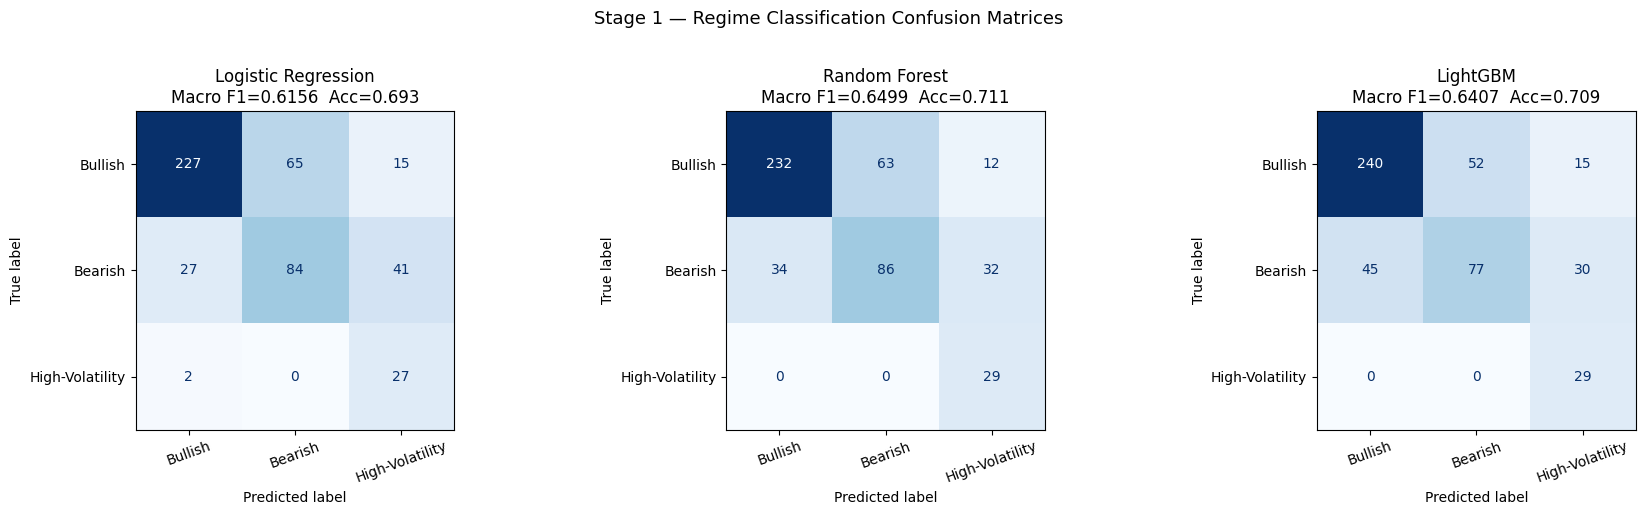

In [13]:
# Figure 2A — S1 Confusion Matrices (3 across)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (yt, yp)) in zip(axes, s1_results.items()):
    ConfusionMatrixDisplay(confusion_matrix(yt, yp),
                           display_labels=list(REGIME_NAMES.values())).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nMacro F1={f1_score(yt, yp, average="macro"):.4f}  '
                 f'Acc={accuracy_score(yt, yp):.3f}')
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Stage 1 — Regime Classification Confusion Matrices', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/trained/fig2a_s1_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


### 3H. Generate Regime Predictions for All Dates

We use the **best Stage 1 model** (by Macro F1) to produce regime predictions for every date in the dataset. These predictions are then merged back into the stock-level dataframe as a feature for Stage 2.

In [14]:
# Best S1 model determined after comparing all 4 — update if XGBoost wins
BEST_S1_MODEL = lgb_s1  # default; compare s1_results summary to confirm

# Map regime_pred directly by date — avoids merge KeyError if column
# assignment fails on a view or stale stage1_df reference
X_all_scaled = scaler_s1.transform(stage1_df[S1_FEATURES].values)
regime_map   = dict(zip(stage1_df['Date'], BEST_S1_MODEL.predict(X_all_scaled)))
df['regime_pred'] = df['Date'].map(regime_map)
df['regime_pred'] = df['regime_pred'].ffill().bfill().fillna(0).astype(int)

assert 'regime_pred' in df.columns
print(f'Regime predictions mapped. Null count: {df["regime_pred"].isnull().sum()}')
print(f'Regime distribution: {df["regime_pred"].value_counts().sort_index().to_dict()}')
df[['Date', 'Encoded_Ticker', 'regime_pred', 'signal']].head(10)


Regime predictions mapped. Null count: 0
Regime distribution: {0: 641365, 1: 275205, 2: 274040}


,Date,Encoded_Ticker,regime_pred,signal
0,2016-03-09,0,0,1
1,2016-03-10,0,0,1
2,2016-03-11,0,0,1
3,2016-03-14,0,0,1
4,2016-03-15,0,0,2
5,2016-03-16,0,0,1
6,2016-03-17,0,0,1
7,2016-03-18,0,0,1
8,2016-03-21,0,0,1
9,2016-03-22,0,0,1


In [15]:
df.to_csv("data/model/regime_pred.csv", index=False)

---
## 4. Stage 2 — Stock-Level Buy / Hold / Sell Classification

### 4A. Prepare Stage 2 Dataset

In [16]:
# ── Stage 2 base features — 9 (minimal, high-signal) ─────────────────────────
# Dropped vs previous: HL_range (corr=0.70 with ATR_Pct), Ret_Lag2/Lag3
#   (near-zero importance), Stochastic_K (corr=0.82 with RSI)
S2_FEATURES_BASE = [
    'Ret_Lag1',          # 1-day momentum (Dir_x_Ret1 interaction partner)
    'Ret_5d',            # 5-day trend persistence (Dir_x_Ret5 interaction partner)
    'RSI',               # momentum oscillator (Dir_x_RSI interaction partner)
    'ATR_Pct',           # volatility level (Vol_x_ATR interaction partner)
    'Volatility_Ratio',  # relative vol spike (top importance historically)
    'Price_vs_SMA50',    # medium-term trend anchor (2nd highest importance)
    'Momentum_Deviation',# Close vs 5-day MA — short-term mean reversion
    'BB_Pct',            # Bollinger Band position
    'Vol_Price_Trend',   # volume-confirmed momentum (NEW)
]  # 9 features

# ── Regime interaction features (4) ───────────────────────────────────────────
# Regime_Direction and Regime_VolFlag are computed as intermediates only —
# dropped as standalone features (captured by the interaction terms)
df['Regime_Direction'] = df['regime_pred'].map({0: 1, 1: -1, 2: 0}).astype(float)
df['Regime_VolFlag']   = (df['regime_pred'] == 2).astype(float)
df['Dir_x_Ret5']       = df['Regime_Direction'] * df['Ret_5d']
df['Dir_x_RSI']        = df['Regime_Direction'] * (df['RSI'] / 100.0)
df['Vol_x_ATR']        = df['Regime_VolFlag']   * df['ATR_Pct']

INTERACTION_FEATURES = [
    'regime_pred',   # raw regime label — categorical split anchor
    'Dir_x_Ret5',    # direction × 5-day return (horizon-aligned)
    'Dir_x_RSI',     # direction × RSI
    'Vol_x_ATR',     # High-Vol flag × ATR (top interaction by importance)
]  # 4 interaction features

S2_FEATURES_REGIME = S2_FEATURES_BASE + INTERACTION_FEATURES  # 13 total

df_s2 = df[S2_FEATURES_REGIME + ['Date', 'signal', 'y_return_5d']].dropna()
df_s2 = df_s2.sort_values('Date').reset_index(drop=True)

print(f'Stage 2 dataset: {df_s2.shape}')
print(f'S2 features ({len(S2_FEATURES_REGIME)}): {S2_FEATURES_REGIME}')
print(f'Signal: {df_s2["signal"].value_counts().to_dict()}')


Stage 2 dataset: (1190610, 16)
S2 features (13): ['Ret_Lag1', 'Ret_5d', 'RSI', 'ATR_Pct', 'Volatility_Ratio', 'Price_vs_SMA50', 'Momentum_Deviation', 'BB_Pct', 'Vol_Price_Trend', 'regime_pred', 'Dir_x_Ret5', 'Dir_x_RSI', 'Vol_x_ATR']
Signal: {1: 832869, 0: 178871, 2: 178870}


### 4B. Chronological Train/Test Split

In [17]:
split_date_s2 = df_s2['Date'].quantile(0.8)
train_s2 = df_s2[df_s2['Date'] <= split_date_s2]
test_s2  = df_s2[df_s2['Date'] >  split_date_s2]

X_train_s2 = train_s2[S2_FEATURES_REGIME].values
y_train_s2 = train_s2['signal'].values
X_test_s2  = test_s2[S2_FEATURES_REGIME].values
y_test_s2  = test_s2['signal'].values

X_train_s2_base = train_s2[S2_FEATURES_BASE].values
X_test_s2_base  = test_s2[S2_FEATURES_BASE].values

scaler_s2 = StandardScaler()
X_train_s2_sc      = scaler_s2.fit_transform(X_train_s2)
X_test_s2_sc       = scaler_s2.transform(X_test_s2)

scaler_s2_base = StandardScaler()
X_train_s2_base_sc = scaler_s2_base.fit_transform(X_train_s2_base)
X_test_s2_base_sc  = scaler_s2_base.transform(X_test_s2_base)

print(f'Stage 2 Train: {len(train_s2):,} | Test: {len(test_s2):,} | Split: {split_date_s2.date()}')

# ── Label distribution sanity check ──────────────────────────────────────────
for cls, name in [(0,'Sell'),(1,'Hold'),(2,'Buy')]:
    n = (y_train_s2 == cls).sum()
    print(f'  Train {name}: {n:,}  ({n/len(y_train_s2):.1%})')

# ══════════════════════════════════════════════════════════════════════════════
# WEIGHTING STRATEGY — v4: tunable SELL_BUY_WEIGHT
# ──────────────────────────────────────────────────────────────────────────────
# class_weight='balanced' auto-sets Sell/Buy weight to ~4.67× for 70/15/15.
# Results showed Hold recall≈53% vs Sell/Buy≈27% at that ratio — still dominant.
# SELL_BUY_WEIGHT=6.0 pushes toward equal recall across all three classes.
#
# HyperparameterTuning.ipynb tunes this in [3.0–12.0] per model using
# balanced_accuracy_score (mean per-class recall) as the Optuna objective,
# then writes back the optimal value per model.
# ══════════════════════════════════════════════════════════════════════════════
SELL_BUY_WEIGHT = 6.0
CW = {0: SELL_BUY_WEIGHT, 1: 1.0, 2: SELL_BUY_WEIGHT}

def make_xgb_sw(labels, sell_buy_weight=SELL_BUY_WEIGHT):
    'Per-sample weights for XGBoost equivalent to class_weight dict CW.'
    labels = np.asarray(labels)
    w = np.where(labels == 1, 1.0, float(sell_buy_weight)).astype(np.float32)
    return (w / w.mean()).astype(np.float32)

xgb_train_sw_s2      = make_xgb_sw(y_train_s2)
xgb_train_sw_s2_base = make_xgb_sw(y_train_s2)

print(f'Class weights: Sell={CW[0]}  Hold={CW[1]}  Buy={CW[2]}')
print(f'XGB weights — Hold:{xgb_train_sw_s2[y_train_s2==1].mean():.3f}  '
      f'Sell:{xgb_train_sw_s2[y_train_s2==0].mean():.3f}  '
      f'Buy:{xgb_train_sw_s2[y_train_s2==2].mean():.3f}')

# ── Error report utility (no calibration — just raw model predictions) ────────
def cross_error_report(y_true, y_pred, label=""):
    n           = len(y_true)
    correct     = (y_pred == y_true).sum()
    cross       = ((y_pred==2)&(y_true==0)).sum() + ((y_pred==0)&(y_true==2)).sum()
    hold_adj    = ((y_pred != y_true) & ((y_pred==1) | (y_true==1))).sum()
    total_wrong = n - correct
    print(f'\n{label}')
    print(f'  Correct          : {correct:>8,}  ({correct/n:.1%})')
    print(f'  Total wrong      : {total_wrong:>8,}  ({total_wrong/n:.1%})')
    print(f'    Cross Sell↔Buy : {cross:>8,}  ({cross/n:.1%})')
    print(f'    Hold-adjacent  : {hold_adj:>8,}  ({hold_adj/n:.1%})')
    print(classification_report(y_true, y_pred,
          target_names=list(SIGNAL_NAMES.values()), digits=3))


Stage 2 Train: 952,633 | Test: 237,977 | Split: 2024-01-17
  Train Sell: 142,944  (15.0%)
  Train Hold: 666,820  (70.0%)
  Train Buy: 142,869  (15.0%)
Class weights: Sell=6.0  Hold=1.0  Buy=6.0
XGB weights — Hold:0.400  Sell:2.400  Buy:2.400


### 4C. Model 1 — Logistic Regression (Baseline)

In [18]:
# class_weight="balanced" handles 70/15/15 imbalance — nothing passed to fit()
lr_s2 = LogisticRegression(max_iter=2000, C=0.1, solver='lbfgs',
                            class_weight=CW, random_state=SEED)
lr_s2.fit(X_train_s2_sc, y_train_s2)

lr_s2_base = LogisticRegression(max_iter=2000, C=0.1, solver='lbfgs',
                                 class_weight=CW, random_state=SEED)
lr_s2_base.fit(X_train_s2_base_sc, y_train_s2)

y_pred_lr_s2      = lr_s2.predict(X_test_s2_sc)
y_pred_lr_s2_base = lr_s2_base.predict(X_test_s2_base_sc)

cross_error_report(y_test_s2, y_pred_lr_s2,      "=== LR (regime) ===")
cross_error_report(y_test_s2, y_pred_lr_s2_base, "=== LR (base)   ===")



=== LR (regime) ===
  Correct          :   74,985  (31.5%)
  Total wrong      :  162,992  (68.5%)
    Cross Sell↔Buy :   26,761  (11.2%)
    Hold-adjacent  :  136,231  (57.2%)
              precision    recall  f1-score   support

        Sell      0.146     0.462     0.222     35927
        Hold      0.735     0.281     0.406    166049
         Buy      0.192     0.326     0.242     36001

    accuracy                          0.315    237977
   macro avg      0.358     0.356     0.290    237977
weighted avg      0.564     0.315     0.354    237977


=== LR (base)   ===
  Correct          :   63,332  (26.6%)
  Total wrong      :  174,645  (73.4%)
    Cross Sell↔Buy :   29,796  (12.5%)
    Hold-adjacent  :  144,849  (60.9%)
              precision    recall  f1-score   support

        Sell      0.142     0.428     0.213     35927
        Hold      0.738     0.198     0.312    166049
         Buy      0.178     0.420     0.250     36001

    accuracy                          0.266    

### 4D. Model 2 — Random Forest

In [19]:
# CW dict gives explicit 6× weight to Sell/Buy vs Hold
rf_s2 = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    min_samples_leaf=20,
    max_features=0.6,
    max_samples=0.7,
    class_weight=CW,
    random_state=SEED, n_jobs=-1
)
rf_s2.fit(X_train_s2_sc, y_train_s2)

rf_s2_base = RandomForestClassifier(
    n_estimators=150, max_depth=6, min_samples_leaf=20,
    max_features=0.6, max_samples=0.7,
    class_weight=CW,
    random_state=SEED, n_jobs=-1
)
rf_s2_base.fit(X_train_s2_base_sc, y_train_s2)

y_pred_rf_s2      = rf_s2.predict(X_test_s2_sc)
y_pred_rf_s2_base = rf_s2_base.predict(X_test_s2_base_sc)

cross_error_report(y_test_s2, y_pred_rf_s2,      "=== RF (regime) ===")
cross_error_report(y_test_s2, y_pred_rf_s2_base, "=== RF (base)   ===")



=== RF (regime) ===
  Correct          :   62,892  (26.4%)
  Total wrong      :  175,085  (73.6%)
    Cross Sell↔Buy :   29,185  (12.3%)
    Hold-adjacent  :  145,900  (61.3%)
              precision    recall  f1-score   support

        Sell      0.151     0.598     0.241     35927
        Hold      0.744     0.185     0.297    166049
         Buy      0.198     0.296     0.237     36001

    accuracy                          0.264    237977
   macro avg      0.364     0.360     0.258    237977
weighted avg      0.571     0.264     0.279    237977


=== RF (base)   ===
  Correct          :   62,704  (26.3%)
  Total wrong      :  175,273  (73.7%)
    Cross Sell↔Buy :   29,141  (12.2%)
    Hold-adjacent  :  146,132  (61.4%)
              precision    recall  f1-score   support

        Sell      0.149     0.426     0.220     35927
        Hold      0.745     0.182     0.293    166049
         Buy      0.182     0.476     0.263     36001

    accuracy                          0.263    

### 4E. Model 3 — LightGBM

In [20]:
lgb_s2 = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=63,
    min_child_samples=20,
    colsample_bytree=0.8,
    subsample=0.8,
    reg_alpha=0.3,
    reg_lambda=0.5,
    min_split_gain=0.01,
    class_weight=CW,
    random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_s2.fit(
    X_train_s2_sc, y_train_s2,
    eval_set=[(X_test_s2_sc, y_test_s2)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)

lgb_s2_base = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=7, num_leaves=63,
    min_child_samples=20, colsample_bytree=0.8, subsample=0.8,
    reg_alpha=0.3, reg_lambda=0.5, min_split_gain=0.01,
    class_weight=CW, random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_s2_base.fit(
    X_train_s2_base_sc, y_train_s2,
    eval_set=[(X_test_s2_base_sc, y_test_s2)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)

y_pred_lgb_s2      = lgb_s2.predict(X_test_s2_sc)
y_pred_lgb_s2_base = lgb_s2_base.predict(X_test_s2_base_sc)

cross_error_report(y_test_s2, y_pred_lgb_s2,      "=== LightGBM (regime) ===")
cross_error_report(y_test_s2, y_pred_lgb_s2_base, "=== LightGBM (base)   ===")



=== LightGBM (regime) ===
  Correct          :   68,222  (28.7%)
  Total wrong      :  169,755  (71.3%)
    Cross Sell↔Buy :   28,683  (12.1%)
    Hold-adjacent  :  141,072  (59.3%)
              precision    recall  f1-score   support

        Sell      0.151     0.518     0.234     35927
        Hold      0.750     0.226     0.347    166049
         Buy      0.187     0.337     0.241     36001

    accuracy                          0.287    237977
   macro avg      0.363     0.360     0.274    237977
weighted avg      0.574     0.287     0.314    237977


=== LightGBM (base)   ===
  Correct          :   59,110  (24.8%)
  Total wrong      :  178,867  (75.2%)
    Cross Sell↔Buy :   30,393  (12.8%)
    Hold-adjacent  :  148,474  (62.4%)
              precision    recall  f1-score   support

        Sell      0.148     0.444     0.222     35927
        Hold      0.755     0.157     0.260    166049
         Buy      0.179     0.476     0.261     36001

    accuracy                       

In [21]:
# XGBoost has no class_weight parameter — pass inv_freq weights to fit() instead.
# inv_freq_weights() gives exactly the same correction as class_weight="balanced".
xgb_s2 = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.3,
    reg_lambda=0.5,
    gamma=0.05,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=SEED, n_jobs=-1, verbosity=0
)
xgb_s2.fit(
    X_train_s2_sc, y_train_s2,
    sample_weight=xgb_train_sw_s2,      # inv_freq only — equivalent to class_weight="balanced"
    eval_set=[(X_test_s2_sc, y_test_s2)],
    verbose=False
)

xgb_s2_base = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6, min_child_weight=5,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.3, reg_lambda=0.5,
    gamma=0.05, use_label_encoder=False, eval_metric='mlogloss',
    random_state=SEED, n_jobs=-1, verbosity=0
)
xgb_s2_base.fit(
    X_train_s2_base_sc, y_train_s2,
    sample_weight=xgb_train_sw_s2_base,
    eval_set=[(X_test_s2_base_sc, y_test_s2)],
    verbose=False
)

y_pred_xgb_s2      = xgb_s2.predict(X_test_s2_sc)
y_pred_xgb_s2_base = xgb_s2_base.predict(X_test_s2_base_sc)

cross_error_report(y_test_s2, y_pred_xgb_s2,      "=== XGBoost (regime) ===")
cross_error_report(y_test_s2, y_pred_xgb_s2_base, "=== XGBoost (base)   ===")



=== XGBoost (regime) ===
  Correct          :   72,893  (30.6%)
  Total wrong      :  165,084  (69.4%)
    Cross Sell↔Buy :   27,944  (11.7%)
    Hold-adjacent  :  137,140  (57.6%)
              precision    recall  f1-score   support

        Sell      0.153     0.485     0.232     35927
        Hold      0.751     0.260     0.387    166049
         Buy      0.184     0.340     0.239     36001

    accuracy                          0.306    237977
   macro avg      0.363     0.362     0.286    237977
weighted avg      0.575     0.306     0.341    237977


=== XGBoost (base)   ===
  Correct          :   69,409  (29.2%)
  Total wrong      :  168,568  (70.8%)
    Cross Sell↔Buy :   28,941  (12.2%)
    Hold-adjacent  :  139,627  (58.7%)
              precision    recall  f1-score   support

        Sell      0.150     0.403     0.219     35927
        Hold      0.755     0.235     0.359    166049
         Buy      0.176     0.441     0.252     36001

    accuracy                         

---
## 5. Feature Ablation Study

Isolating the contribution of each feature group using LightGBM (best/fastest model) as the ablation vehicle.

In [22]:
# ── Feature Ablation Study ───────────────────────────────────────────────────
# Tests different feature subsets to quantify each group's contribution.
# All groups use the current feature set only (no legacy features).
ABLATION_GROUPS = {
    'All + Interactions':      S2_FEATURES_REGIME,                    # full 13-feature set
    'All + Regime (no ixn)':   S2_FEATURES_BASE + ['regime_pred'],    # base + raw regime only
    'No Regime':               S2_FEATURES_BASE,                       # base 9 features only
    'Momentum + Interactions': [
        'Ret_Lag1', 'Ret_5d', 'RSI',
        'regime_pred', 'Dir_x_Ret5', 'Dir_x_RSI',
    ],
    'Volatility + Interactions': [
        'ATR_Pct', 'Volatility_Ratio', 'Vol_Price_Trend',
        'regime_pred', 'Vol_x_ATR',
    ],
    'Momentum Only':    ['Ret_Lag1', 'Ret_5d', 'RSI'],
    'Volatility Only':  ['ATR_Pct', 'Volatility_Ratio', 'Vol_Price_Trend'],
    'Trend Only':       ['Price_vs_SMA50', 'Momentum_Deviation', 'BB_Pct'],
    'No Interactions':  S2_FEATURES_BASE + ['regime_pred'],
}

ablation_results = []
for name, feats in ABLATION_GROUPS.items():
    # Skip if any feature not in data (safety guard)
    missing = [f for f in feats if f not in df_s2.columns]
    if missing:
        print(f'  SKIP {name}: missing {missing}')
        continue
    abl_scaler = StandardScaler()
    X_tr = abl_scaler.fit_transform(train_s2[feats].values)
    X_te = abl_scaler.transform(test_s2[feats].values)
    model = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        reg_alpha=0.3, reg_lambda=0.5, min_split_gain=0.01,
        min_child_samples=20, class_weight='balanced',
        random_state=SEED, n_jobs=-1, verbose=-1
    )
    model.fit(X_tr, y_train_s2)
    y_pred = model.predict(X_te)
    cross = ((y_pred==2)&(y_test_s2==0)).sum() + ((y_pred==0)&(y_test_s2==2)).sum()
    ablation_results.append({
        'Feature Group': name,
        'N Features':  len(feats),
        'Macro F1':    f1_score(y_test_s2, y_pred, average='macro'),
        'Sell F1':     f1_score(y_test_s2, y_pred, average=None, labels=[0])[0],
        'Buy F1':      f1_score(y_test_s2, y_pred, average=None, labels=[2])[0],
        'Cross Err%':  cross / len(y_test_s2),
        'Accuracy':    accuracy_score(y_test_s2, y_pred),
    })

ablation_df = pd.DataFrame(ablation_results).sort_values('Macro F1', ascending=False)
print('=== Feature Ablation Results ===')
print(ablation_df.to_string(index=False))


=== Feature Ablation Results ===
            Feature Group  N Features  Macro F1  Sell F1   Buy F1  Cross Err%  Accuracy
  Momentum + Interactions           6  0.361088 0.186686 0.231160    0.059249  0.505692
    All + Regime (no ixn)          10  0.353046 0.198269 0.235322    0.080092  0.464856
          No Interactions          10  0.353046 0.198269 0.235322    0.080092  0.464856
       All + Interactions          13  0.352565 0.201450 0.234311    0.079957  0.462188
Volatility + Interactions           5  0.348101 0.190171 0.225732    0.074898  0.466873
            Momentum Only           3  0.343485 0.170007 0.241199    0.072238  0.461448
                No Regime           9  0.341541 0.181298 0.252927    0.087845  0.436181
          Volatility Only           3  0.337835 0.168356 0.244758    0.082386  0.443022
               Trend Only           3  0.337703 0.155093 0.244101    0.074986  0.455166


In [23]:
# Figure 2 — Stage 2 Analysis (2×2 consolidated)
# Populated after walk-forward and regime impact cells — see combined cell below
print("Ablation done — combined S2 figure generated after Section 8.")


Ablation done — combined S2 figure generated after Section 8.


---
## 6. Walk-Forward Cross-Validation

Time-series CV using `sklearn.TimeSeriesSplit`. Ensures no future data leaks into training at any fold.

In [24]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# Use LightGBM as walk-forward model
# Fresh scaler per fold to avoid data leakage across folds
X_wf_raw = df_s2[S2_FEATURES_REGIME].values
y_wf     = df_s2['signal'].values

wf_results = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_wf_raw)):
    X_wf_raw_tr, X_wf_raw_te = X_wf_raw[train_idx], X_wf_raw[test_idx]
    y_wf_tr, y_wf_te         = y_wf[train_idx],     y_wf[test_idx]

    wf_scaler = StandardScaler()
    X_wf_tr   = wf_scaler.fit_transform(X_wf_raw_tr)
    X_wf_te   = wf_scaler.transform(X_wf_raw_te)

    model = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        reg_alpha=0.3, reg_lambda=0.5, min_split_gain=0.01,
        class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1
    )
    model.fit(X_wf_tr, y_wf_tr)

    val_cut_wf = int(len(train_idx) * 0.80)
    X_wf_val = wf_scaler.transform(X_wf_raw[train_idx[val_cut_wf:]])
    y_wf_val = y_wf[train_idx[val_cut_wf:]]
    y_pred = model.predict(X_wf_te)

    wf_results.append({
        'Fold':       fold + 1,
        'Train Size': len(train_idx),
        'Test Size':  len(test_idx),
        'Accuracy':   accuracy_score(y_wf_te, y_pred),
        'Macro F1':   f1_score(y_wf_te, y_pred, average='macro'),
    })

wf_df = pd.DataFrame(wf_results)
print('=== Walk-Forward CV Results (LightGBM, Stage 2) ===')
print(wf_df.to_string(index=False))
print(f'\nMean Macro F1: {wf_df["Macro F1"].mean():.4f} ± {wf_df["Macro F1"].std():.4f}')


=== Walk-Forward CV Results (LightGBM, Stage 2) ===
 Fold  Train Size  Test Size  Accuracy  Macro F1
    1      198435     198435  0.373674  0.311603
    2      396870     198435  0.347167  0.329673
    3      595305     198435  0.368307  0.326493
    4      793740     198435  0.466062  0.356224
    5      992175     198435  0.441585  0.347981

Mean Macro F1: 0.3344 ± 0.0178


In [25]:
print("Walk-forward done — combined S2 figure generated after Section 8.")


Walk-forward done — combined S2 figure generated after Section 8.


---
## 7. Final Comparative Evaluation — Stage 2

In [26]:
s2_results = [
    ('Logistic Regression (regime)', y_test_s2, y_pred_lr_s2),
    ('Logistic Regression (base)', y_test_s2, y_pred_lr_s2_base),
    ('Random Forest (regime)', y_test_s2, y_pred_rf_s2),
    ('Random Forest (base)', y_test_s2, y_pred_rf_s2_base),
    ('LightGBM (regime)', y_test_s2, y_pred_lgb_s2),
    ('LightGBM (base)',  y_test_s2, y_pred_lgb_s2_base),
    ('XGBoost (regime)', y_test_s2, y_pred_xgb_s2),
    ('XGBoost (base)',   y_test_s2, y_pred_xgb_s2_base),
]

summary_s2 = pd.DataFrame([
    {
        'Model': name,
        'Has Regime': 'regime' in name,
        'Accuracy': accuracy_score(yt, yp),
        'Macro F1':  f1_score(yt, yp, average='macro'),
        'Weighted F1': f1_score(yt, yp, average='weighted'),
    }
    for name, yt, yp in s2_results
]).sort_values('Macro F1', ascending=False).reset_index(drop=True)

print('=== Stage 2 Final Model Comparison ===')
print(summary_s2.to_string(index=False))

=== Stage 2 Final Model Comparison ===
                       Model  Has Regime  Accuracy  Macro F1  Weighted F1
Logistic Regression (regime)        True  0.315093  0.290176     0.353755
            XGBoost (regime)        True  0.306303  0.285995     0.341071
              XGBoost (base)       False  0.291663  0.276540     0.321524
           LightGBM (regime)        True  0.286675  0.273869     0.313831
        Random Forest (base)       False  0.263488  0.258725     0.277365
  Logistic Regression (base)       False  0.266127  0.258237     0.287661
      Random Forest (regime)        True  0.264278  0.258016     0.279075
             LightGBM (base)       False  0.248385  0.247281     0.254005


In [27]:
# Regime impact: delta between paired regime vs base models
regime_delta = pd.DataFrame([
    {'Model': 'Logistic Regression',
     'ΔMacro F1': f1_score(y_test_s2, y_pred_lr_s2, average='macro') -
                  f1_score(y_test_s2, y_pred_lr_s2_base, average='macro')},
    {'Model': 'Random Forest',
     'ΔMacro F1': f1_score(y_test_s2, y_pred_rf_s2, average='macro') -
                  f1_score(y_test_s2, y_pred_rf_s2_base, average='macro')},
    {'Model': 'LightGBM',
     'ΔMacro F1': f1_score(y_test_s2, y_pred_lgb_s2, average='macro') -
                  f1_score(y_test_s2, y_pred_lgb_s2_base, average='macro')},
    {'Model': 'XGBoost',
     'ΔMacro F1': f1_score(y_test_s2, y_pred_xgb_s2, average='macro') -
                  f1_score(y_test_s2, y_pred_xgb_s2_base, average='macro')}
])
print('=== Regime Signal Impact ===')
print(regime_delta.to_string(index=False))


=== Regime Signal Impact ===
              Model  ΔMacro F1
Logistic Regression   0.031939
      Random Forest  -0.000710
           LightGBM   0.026588
            XGBoost   0.009455


---
## 8. Feature Importance — LightGBM Stage 2

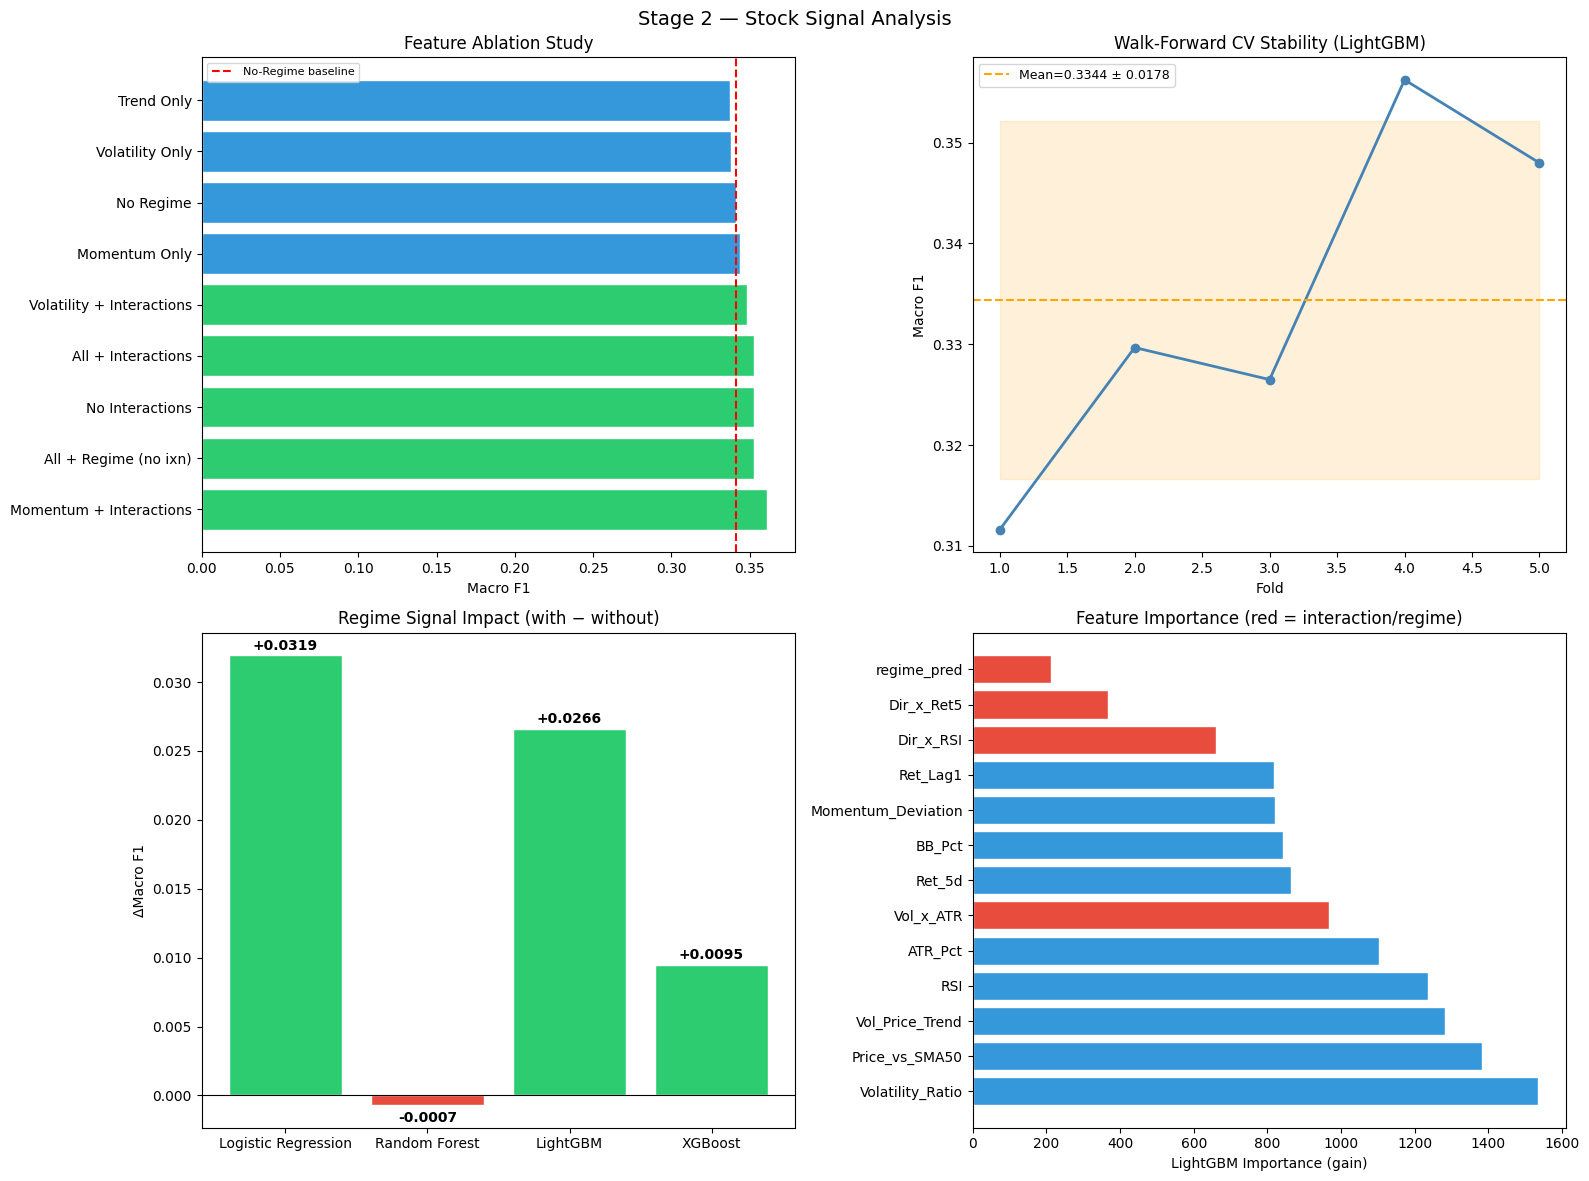

In [28]:
importance_df = pd.DataFrame({
    'Feature':    S2_FEATURES_REGIME,
    'Importance': lgb_s2.feature_importances_
}).sort_values('Importance', ascending=False)

# ── Figure 2 — Stage 2 Full Analysis (2×2) ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Stage 2 — Stock Signal Analysis', fontsize=14)

# TL: Feature Ablation
ax = axes[0, 0]
colors = ['#2ecc71' if 'Interaction' in g or 'All' in g else '#3498db'
          for g in ablation_df['Feature Group']]
ax.barh(ablation_df['Feature Group'], ablation_df['Macro F1'],
        color=colors, edgecolor='white')
base_f1 = ablation_df[ablation_df['Feature Group']=='No Regime']['Macro F1'].values
if len(base_f1):
    ax.axvline(base_f1[0], color='red', linestyle='--', lw=1.5, label='No-Regime baseline')
ax.set_xlabel('Macro F1'); ax.set_title('Feature Ablation Study')
ax.legend(fontsize=8)

# TR: Walk-Forward CV
ax = axes[0, 1]
ax.plot(wf_df['Fold'], wf_df['Macro F1'], marker='o', color='steelblue', lw=2)
mean_f1 = wf_df['Macro F1'].mean()
std_f1  = wf_df['Macro F1'].std()
ax.axhline(mean_f1, color='orange', linestyle='--', lw=1.5,
           label=f'Mean={mean_f1:.4f} ± {std_f1:.4f}')
ax.fill_between(wf_df['Fold'], mean_f1 - std_f1, mean_f1 + std_f1,
                alpha=0.15, color='orange')
ax.set_xlabel('Fold'); ax.set_ylabel('Macro F1')
ax.set_title('Walk-Forward CV Stability (LightGBM)')
ax.legend(fontsize=9)

# BL: Regime Impact
ax = axes[1, 0]
colors_ri = ['#2ecc71' if d > 0 else '#e74c3c' for d in regime_delta['ΔMacro F1']]
bars = ax.bar(regime_delta['Model'], regime_delta['ΔMacro F1'],
              color=colors_ri, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
for bar, val in zip(bars, regime_delta['ΔMacro F1']):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (0.0002 if val >= 0 else -0.0004),
            f'{val:+.4f}', ha='center',
            va='bottom' if val >= 0 else 'top', fontsize=10, fontweight='bold')
ax.set_ylabel('ΔMacro F1'); ax.set_title('Regime Signal Impact (with − without)')

# BR: Feature Importance
ax = axes[1, 1]
interaction_feats = set(INTERACTION_FEATURES)
colors_fi = ['#e74c3c' if f in interaction_feats else '#3498db'
             for f in importance_df['Feature']]
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color=colors_fi, edgecolor='white')
ax.set_xlabel('LightGBM Importance (gain)')
ax.set_title('Feature Importance (red = interaction/regime)')

plt.tight_layout()
plt.savefig('plots/trained/fig2_s2_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Save Models & Results

In [29]:
import pickle, os
os.makedirs('results', exist_ok=True)
os.makedirs('models/trained', exist_ok=True)

with open('models/trained/lr_s1.pkl',    'wb') as f: pickle.dump(lr_s1,    f)
with open('models/trained/rf_s1.pkl',    'wb') as f: pickle.dump(rf_s1,    f)
with open('models/trained/lgb_s1.pkl',   'wb') as f: pickle.dump(lgb_s1,   f)
with open('models/trained/scaler_s1.pkl','wb') as f: pickle.dump(scaler_s1, f)
with open('models/trained/lr_s2.pkl',    'wb') as f: pickle.dump(lr_s2,    f)
with open('models/trained/rf_s2.pkl',    'wb') as f: pickle.dump(rf_s2,    f)
with open('models/trained/lgb_s2.pkl',   'wb') as f: pickle.dump(lgb_s2,   f)
with open('models/trained/xgb_s1.pkl',   'wb') as f: pickle.dump(xgb_s1,   f)
with open('models/trained/xgb_s2.pkl',   'wb') as f: pickle.dump(xgb_s2,   f)
with open('models/trained/scaler_s2.pkl','wb') as f: pickle.dump(scaler_s2, f)

summary_s1.to_csv('results/stage1_model_comparison.csv', index=False)
summary_s2.to_csv('results/stage2_model_comparison.csv', index=False)
ablation_df.to_csv('results/ablation_study.csv', index=False)
wf_df.to_csv('results/walk_forward_cv.csv', index=False)
regime_delta.to_csv('results/regime_impact.csv', index=False)
pd.DataFrame({'Feature': S2_FEATURES_REGIME,
              'LGB_Importance': lgb_s2.feature_importances_,
              'XGB_Importance': xgb_s2.feature_importances_}).to_csv(
    'results/feature_importance.csv', index=False)

print(f'Saved. S1_FEATURES={len(S1_FEATURES)}, S2_FEATURES_REGIME={len(S2_FEATURES_REGIME)}')
print('Models and results saved.')


Saved. S1_FEATURES=6, S2_FEATURES_REGIME=13
Models and results saved.
